# TP3.3 : Modèle épidémiologique SIR sur réseau

## Question a) Résolution analytique de l'équation (3.14)

L'équation à résoudre est la suivante :
$$u = \frac{1}{[1 + T(\kappa - 1)(1 - u)]^2} \equiv f(u)$$

Pour simplifier les calculs, on pose la constante $A = T(\kappa - 1)$. L'équation devient :
$$u = \frac{1}{[1 + A(1 - u)]^2}$$

En multipliant par le dénominateur, on obtient :
$$u [1 + A(1 - u)]^2 = 1$$

On développe ensuite l'expression:
$$u [1 + 2A(1 - u) + A^2(1 - u)^2] = 1$$
$$u [1 + 2A - 2Au + A^2(1 - 2u + u^2)] = 1$$
$$u [1 + 2A - 2Au + A^2 - 2A^2u + A^2u^2] = 1$$

En regroupant les termes selon les puissances de $u$, on obtient:
$$A^2 u^3 - 2A(A + 1) u^2 + (A + 1)^2 u - 1 = 0$$

On remarque que si $u = 1$, l'équation (3.14) donne $1 = 1 / [1 + 0]^2 = 1$. Donc, $(u - 1)$ est un facteur du polynôme.

Par division polynomiale, on obtient :
$$(u - 1) [A^2 u^2 - (A^2 + 2A) u + 1] = 0$$

On cherche les racines de la partie droite de l'équation. Les deux autres racines sont donc :
$$u = \frac{(A^2 + 2A) \pm \sqrt{A^4 + 4A^3}}{2A^2}$$

Les trois racines sont :

1.  $$u_1 = \frac{A^2 + 2A + \sqrt{A^4 + 4A^3}}{2A^2}$$
2.  $$u_2 = \frac{A^2 + 2A - \sqrt{A^4 + 4A^3}}{2A^2}$$
3.  $$u_3 = 1$$

Le résultat des racines peut être calculé manuellement, ou numériquement avec la fonction suivante:

In [3]:
import numpy as np

def get_analytical_roots(T, kappa):
    """Calcule les 3 racines analytiques pour une valeur de T donnée."""
    if T == 0:
        return [1.0] # Cas limite
    
    A = T * (kappa - 1)
    delta = A**4 + 4*A**3
    
    u1 = (A**2 + 2*A + np.sqrt(delta)) / (2 * A**2)
    u2 = (A**2 + 2*A - np.sqrt(delta)) / (2 * A**2)
    u3 = 1.0
    
    return sorted([u1, u2, u3])

print(f"Racines analytiques pour T=0.3 : {get_analytical_roots(0.3, 5)}")

Racines analytiques pour T=0.3 : [0.29250033360026706, 1.0, 2.3741663330663996]


## Question b) Sélection de la solution physique

La variable $u$ représente une probabilité, elle doit donc obligatoirement satisfaire la condition $0 \le u \le 1$. Parmi les solutions obtenues à la question précédente, la valeur $u \approx 2.374$ est rejetée car elle est supérieure à 1, ce qui est physiquement impossible. La solution $u = 1$ correspond au cas trivial où aucune transmission n’a lieu au sein de la population, ce qui implique une taille d'épidémie $R_\infty = 0$. Puisque l'énoncé précise que $u$ est la plus petite solution non négative de l'équation (3.14), la solution physiquement pertinente pour décrire la propagation de la maladie est la racine $u \approx 0.2925$ (pour $T=0.3$).

## Question c) Analyse de la taille finale de l'épidémie $R_\infty$

Pour obtenir les différentes valeurs de $u$, on utilise les équations analytiques développées précedement. Le script présenté ci-dessous détaille l'implémentation de cet algorithme ainsi que la boucle de calcul nécessaire pour balayer l'intervalle complet de transmissibilité et identifier dynamiquement le seuil épidémique.

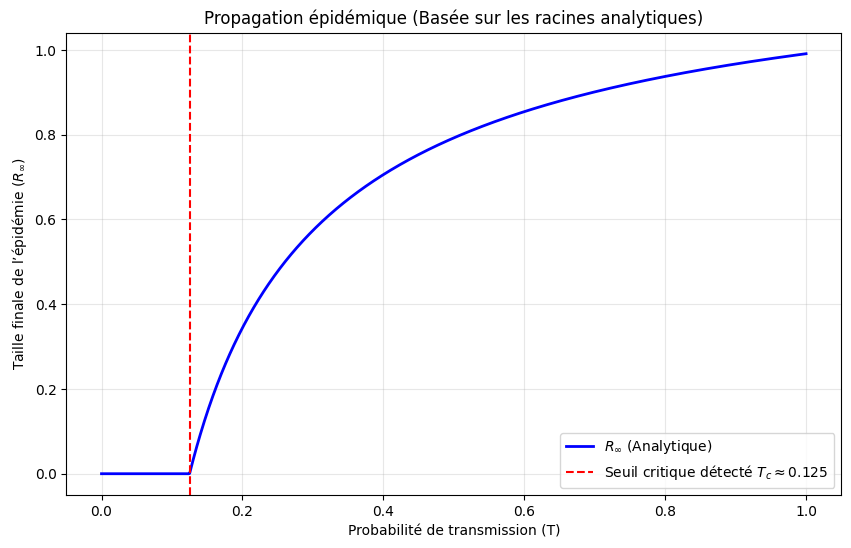

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres
kappa = 5

def R_inf(u, T, kappa):
    return 1 - (1 - T*(1-u))/(1 + T*(kappa-1)*(1-u))

# Calcul de R_inf pour T de 0 à 1
T_values = np.linspace(0, 1, 1000)
R_inf_values = []

for t_val in T_values:
    roots = get_analytical_roots(t_val, kappa)
    u_physique = roots[0]
    
    res = R_inf(u_physique, t_val, kappa)
    R_inf_values.append(res)

# Seuil Tc (où R_inf décolle de zéro)
R_array = np.array(R_inf_values)
seuil_detection = 1e-4 
indices_positifs = np.where(R_array > seuil_detection)[0]

if len(indices_positifs) > 0:
    idx_seuil = indices_positifs[0]
    Tc_detecte = T_values[idx_seuil]
else:
    Tc_detecte = 0

# 3. Graphique
plt.figure(figsize=(10, 6))
plt.plot(T_values, R_inf_values, color='blue', lw=2, label='$R_{\\infty}$ (Analytique)')
plt.axvline(x=Tc_detecte, color='red', linestyle='--', 
            label=f'Seuil critique détecté $T_c \\approx {Tc_detecte:.3f}$')

plt.xlabel('Probabilité de transmission (T)')
plt.ylabel('Taille finale de l’épidémie ($R_{\\infty}$)')
plt.title('Propagation épidémique (Basée sur les racines analytiques)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

L'analyse du graphique de la taille finale de l'épidémie $R_\infty$ en fonction de la probabilité de transmission $T$ révèle un changement qualitatif majeur qui correspond à une transition de phase épidémique détectée numériquement à $T_c \approx 0.125$. Pour des valeurs de $T$ inférieures à ce seuil, la fraction de la population infectée demeure nulle car la maladie ne possède pas une transmissibilité suffisante pour se propager et finit par s'éteindre naturellement après seulement quelques contacts au sein du réseau. Dès que $T$ franchit cette valeur critique, on observe un « décollage » soudain de la courbe où $R_\infty$ croît rapidement, montrant qu'une fraction significative de la population est désormais atteinte par l'agent pathogène. Ce phénomène s'interprète physiquement comme l'atteinte d'un seuil de percolation où la condition de stabilité de la solution triviale $u=1$ est rompue lorsque $2T(\kappa-1) = 1$, ce qui donne précisément $T_c = 1 / [2(5-1)] = 0.125$. À ce point précis, le virus devient assez contagieux pour former une composante géante d'infection à travers le réseau. On peut finalement observer que $R_\infty$ croît de plus en plus lentement à mesure que $T$ augmente pour tendre vers une valeur maximale proche de 1, ce qui signifie que la quasi-totalité de la population finit par être infectée lorsque la transmission est totale. Par exemple, pour un taux de transmission maximal ($T=1$) avec une moyenne de $\kappa=5$, on calcule que $R_\infty$ atteint environ 99,1 % de la population, ce qui signifie que la quasi-totalité des individus finit par être infectée sans jamais atteindre le 100 % absolu pour des raisons statistiques.

## Question d) Résolution numérique par relaxation et Newton-Raphson

On fait maintenant la résolution numérique de l’équation (3.14) par implémentations personnelles des méthodes de relaxation et de Newton-Raphson. On applique ces algorithmes à vingt valeurs de $T$ réparties uniformément sur l’intervalle $[0, 1]$ afin de confronter les résultats numériques aux solutions analytiques développées à la première question. Le code développé pour les deux méthodes est le suivant:

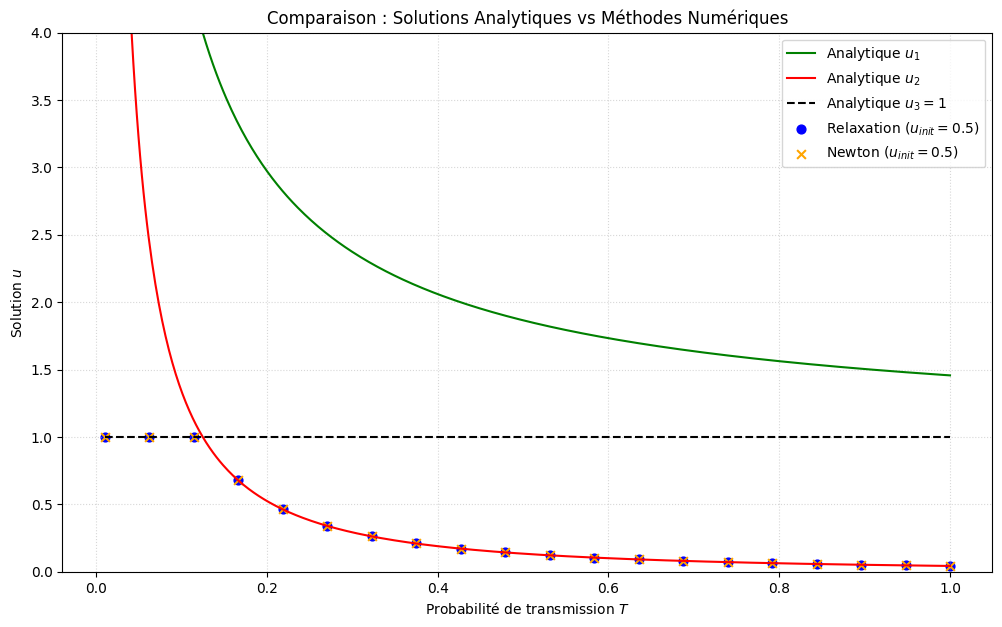

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Paramètres et solveurs ---
kappa = 5
tol = 1e-10
max_iter = 1000

def f(u, T, kappa):
    return 1 / (1 + T*(kappa-1)*(1-u))**2

def df_du(u, T, kappa):
    A = T * (kappa - 1)
    return (2 * A) / (1 + A * (1 - u))**3

def g(u, T, kappa):
    return f(u, T, kappa) - u

def g_prime(u, T, kappa):
    return df_du(u, T, kappa) - 1

def solve_relaxation(T, kappa, u_start, tol, max_iter):
    u = u_start
    for _ in range(max_iter):
        u_new = f(u, T, kappa)
        if abs(u_new - u) < tol: return u_new
        u = u_new
    return u

def solve_newton(T, kappa, u_start, tol, max_iter):
    u = u_start
    for _ in range(max_iter):
        val, der = g(u, T, kappa), g_prime(u, T, kappa)
        if der == 0: return None
        u_new = u - val / der
        if abs(u_new - u) < tol: return u_new
        u = u_new
    return u


T_20 = np.linspace(0.01, 1, 20)

u_relax_points = []
u_newton_points = []

for t in T_20:
    u_r = solve_relaxation(t, kappa, 0.5, tol, max_iter)
    u_n = solve_newton(t, kappa, 0.5, tol, max_iter)
    
    u_relax_points.append(u_r)
    u_newton_points.append(u_n)


T_cont = np.linspace(0.01, 1, 500)

u1_analytique = []
u2_analytique = []
u3_analytique = np.ones_like(T_cont)

for t in T_cont:
    A = t * (kappa - 1)
    delta = A**4 + 4*A**3
    
    # Formules dérivées à la question a)
    u1 = (A**2 + 2*A + np.sqrt(delta)) / (2 * A**2)
    u2 = (A**2 + 2*A - np.sqrt(delta)) / (2 * A**2)
    
    u1_analytique.append(u1)
    u2_analytique.append(u2)

# Graphique Final
plt.figure(figsize=(12, 7))

# Tracé des lignes analytiques
plt.plot(T_cont, u1_analytique, color='green', label='Analytique $u_1$', lw=1.5)
plt.plot(T_cont, u2_analytique, color='red', label='Analytique $u_2$', lw=1.5)
plt.plot(T_cont, u3_analytique, color='black', linestyle='--', label='Analytique $u_3 = 1$', lw=1.5)

# Tracé des points numériques
plt.scatter(T_20, u_relax_points, color='blue', marker='o', s=40, label='Relaxation ($u_{init}=0.5$)')
plt.scatter(T_20, u_newton_points, color='orange', marker='x', s=40, label='Newton ($u_{init}=0.5$)')

plt.ylim(0, 4)
plt.xlabel('Probabilité de transmission $T$')
plt.ylabel('Solution $u$')
plt.title('Comparaison : Solutions Analytiques vs Méthodes Numériques')
plt.legend()
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.show()

L'analyse du graphique de comparaison montre une correspondance parfaite entre les points calculés numériquement et les branches analytiques obtenues à la première question. Avec un point de départ fixé à $u_{init} = 0.5$, la méthode de relaxation et celle de Newton-Raphson convergent toutes deux vers la solution physique $u_2$ ou vers la solution triviale $u_3$ selon la région de $T$ explorée. La méthode de relaxation ne permet pas d'atteindre la branche $u_1$ car elle est mathématiquement contrainte de ne converger que vers des points fixes stables satisfaisant la condition de stabilité $|f'(u)| < 1$. Puisque la dérivée $f'(u)$ est supérieure à l'unité au voisinage de la racine $u_1$, cette dernière agit comme un répulseur qui éloigne systématiquement les itérations de relaxation vers une autre solution. En revanche, la méthode de Newton-Raphson parvient à identifier cette troisième solution instable lorsqu'on utilise une valeur initiale plus élevée, par exemple $u_{init} = 3.5$, car son mécanisme de recherche de racine basé sur la pente locale ne dépend pas de la nature attractive ou répulsive du point fixe.

On peut se convaincre de cette observation en traçant la fonction f(u) et sa dérivé pour plusieurs valeurs de T.

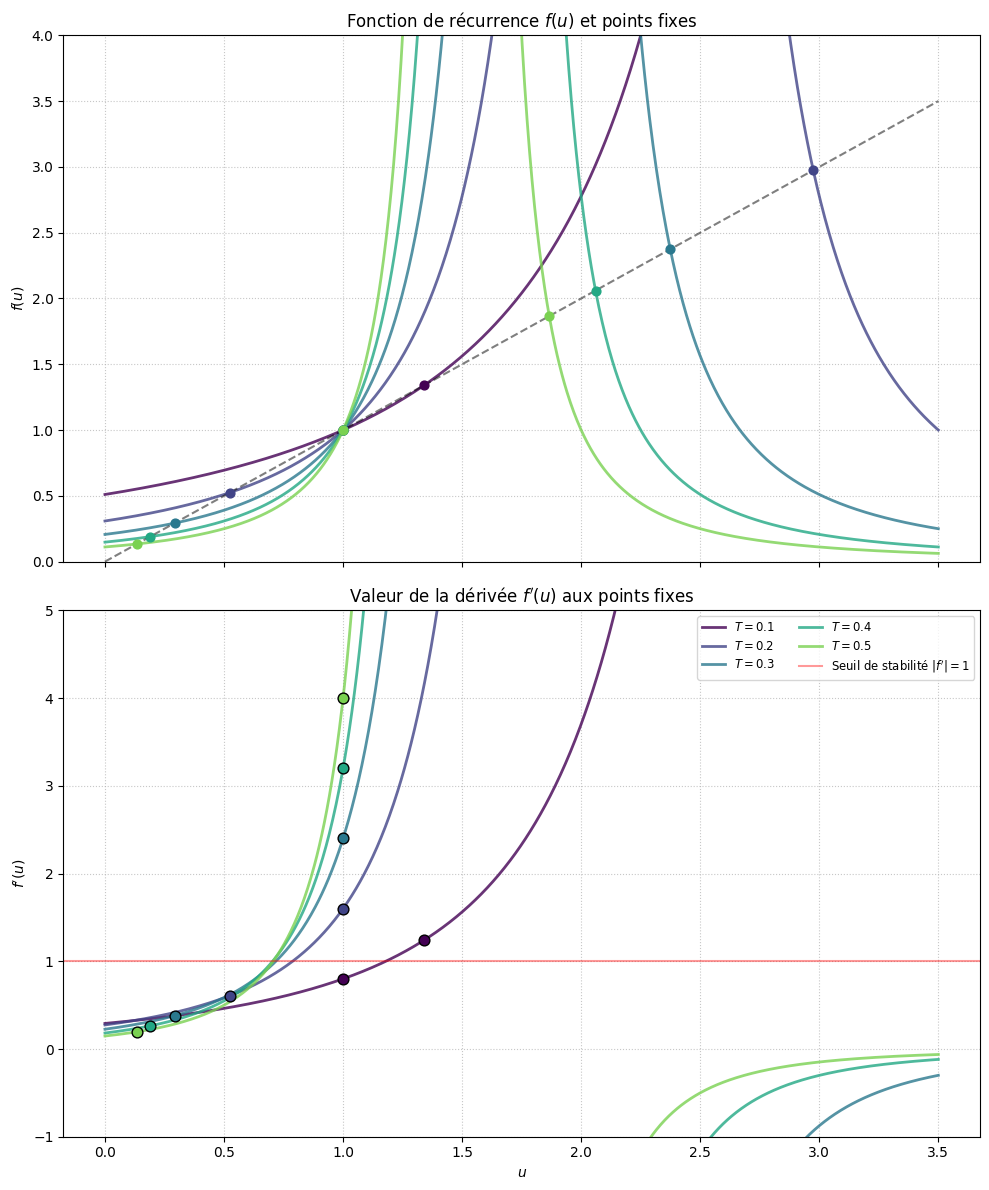

In [67]:
import numpy as np
import matplotlib.pyplot as plt

def f(u, T, k):
    with np.errstate(divide='ignore', invalid='ignore'):
        denom = 1 + T * (k - 1) * (1 - u)
        return 1 / (denom**2)

def df(u, T, k):
    with np.errstate(divide='ignore', invalid='ignore'):
        denom = 1 + T * (k - 1) * (1 - u)
        num = 2 * T * (k - 1)
        return num / (denom**3)

def get_roots(T, k):
    """Calcul analytique des racines de f(u) = u"""
    if T == 0: return [1.0]
    A = T * (k - 1)
    delta = A**4 + 4*A**3
    u1 = (A**2 + 2*A + np.sqrt(delta)) / (2 * A**2)
    u2 = (A**2 + 2*A - np.sqrt(delta)) / (2 * A**2)
    u3 = 1.0
    return [u1, u2, u3]

k = 5
T_values = [0.1, 0.2, 0.3, 0.4, 0.5]
u_range = np.linspace(0, 3.5, 1000)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
colors = plt.cm.viridis(np.linspace(0, 0.8, len(T_values)))

for T, color in zip(T_values, colors):
    f_vals = f(u_range, T, k)
    df_vals = df(u_range, T, k)
    
    # On remplace les valeurs infinies ou trop grandes par NaN pour un tracé propre
    f_vals[f_vals > 50] = np.nan
    df_vals[np.abs(df_vals) > 50] = np.nan

    ax1.plot(u_range, f_vals, color=color, lw=2, alpha=0.8)
    ax2.plot(u_range, df_vals, color=color, lw=2, alpha=0.8, label=f'$T={T}$')

    roots = get_roots(T, k)
    for r in roots:
        if 0 <= r <= 3.5:
            val_f = f(r, T, k)
            val_df = df(r, T, k)
            ax1.scatter(r, val_f, color=color, s=40, zorder=5)
            ax2.scatter(r, val_df, color=color, s=60, edgecolors='black', zorder=5)

# Habillage
ax1.plot(u_range, u_range, 'k--', alpha=0.5, label='$y = u$')
ax1.set_ylabel('$f(u)$')
ax1.set_title('Fonction de récurrence $f(u)$ et points fixes')
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.set_ylim(0, 4)

ax2.axhline(y=1, color='red', linestyle='-', alpha=0.4, label='Seuil de stabilité $|f\'|=1$')
ax2.set_xlabel('$u$')
ax2.set_ylabel("$f'(u)$")
ax2.set_title('Valeur de la dérivée $f\'(u)$ aux points fixes')
ax2.legend(loc='upper right', fontsize='small', ncol=2)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.set_ylim(-1, 5)

plt.tight_layout()
plt.show()

La méthode de **relaxation** s'arrêtee que sur les points "attractifs" (stables), là où la pente f'(u) est plus petite que 1 (sous la ligne rouge du graphique). Si un point est "repoussant" (instable), la relaxation s'en éloigne forcément. 



À l'inverse, **Newton** utilise la pente pour "viser" directement la cible. Cela lui permet d'atteindre n'importe quel point, même s'il est instable, à condition de partir du bon endroit. En résumé, la relaxation suit la tendance naturelle du système, tandis que Newton calcule précisément la position de chaque solution.

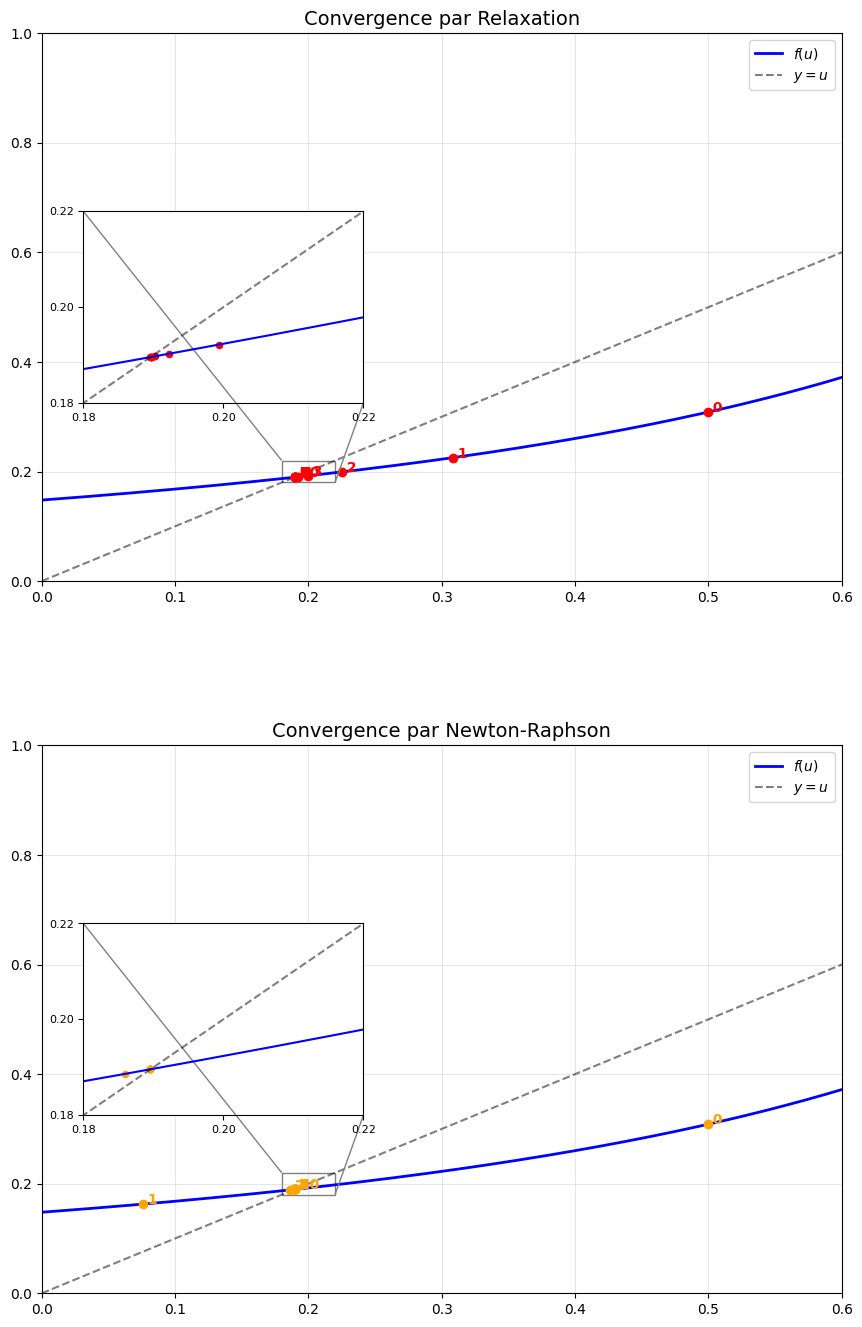

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Sécurité pour les divisions par zéro
def f_safe(u, T, k):
    with np.errstate(divide='ignore', invalid='ignore'):
        denom = 1 + T * (k - 1) * (1 - u)
        return 1 / (denom**2)

# --- Paramètres ---
T_ex = 0.4
k_ex = 5
n_iter = 10
u_range_zoom = np.linspace(0, 1, 500)
f_curve_zoom = f_safe(u_range_zoom, T_ex, k_ex)

u_rel_zoom = relaxation_steps(T_ex, k_ex, 0.5, n_iter) 
u_new_zoom = newton_steps(T_ex, k_ex, 0.5, n_iter)   

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 14))

configs = [
    (ax1, u_rel_zoom, 'Relaxation', 'red'),
    (ax2, u_new_zoom, 'Newton-Raphson', 'orange')
]

for ax, u_data, title, color in configs:
    ax.plot(u_range_zoom, f_curve_zoom, 'b-', label='$f(u)$', lw=2)
    ax.plot(u_range_zoom, u_range_zoom, 'k--', alpha=0.5, label='$y=u$')
    ax.scatter(u_data, f_safe(u_data, T_ex, k_ex), color=color, zorder=5)
    
    for i, u_val in enumerate(u_data):
        if 0 <= u_val <= 0.6:
            ax.text(u_val, f_safe(u_val, T_ex, k_ex), f' {i}', color=color, fontsize=10, fontweight='bold')
    
    ax.set_title(f'Convergence par {title}', fontsize=14)
    ax.set_xlim(0, 0.6)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right')

    # Zoom
    ax_ins = inset_axes(ax, width="35%", height="35%", loc='center left', borderpad=3)
    ax_ins.plot(u_range_zoom, f_curve_zoom, 'b-')
    ax_ins.plot(u_range_zoom, u_range_zoom, 'k--', alpha=0.5)
    ax_ins.scatter(u_data, f_safe(u_data, T_ex, k_ex), color=color, s=20)
    
    ax_ins.set_xlim(0.18, 0.22) 
    ax_ins.set_ylim(0.18, 0.22)
    ax_ins.set_xticks([0.18, 0.20, 0.22])
    ax_ins.set_yticks([0.18, 0.20, 0.22])
    ax_ins.tick_params(labelsize=8)
    mark_inset(ax, ax_ins, loc1=2, loc2=4, fc="none", ec="0.5")

# Remplacer tight_layout par subplots_adjust pour éviter l'erreur
plt.subplots_adjust(hspace=0.3, left=0.1, right=0.9, top=0.95, bottom=0.05)
plt.show()

La méthode de Newton est beaucoup plus rapide car elle utilise la pente de la courbe pour "viser" directement la solution, ce qui lui permet de faire de grands bonds vers le résultat. À l'inverse, la méthode de relaxation avance lentement, étape par étape, comme si elle suivait un escalier. Sur les graphiques, on voit que Newton trouve la réponse en seulement deux ou trois coups, alors que la relaxation demande plus d'itérations pour arriver au même endroit.